# Generatie van Synthetische Storingsdata (Synthetic Data Generation)

**Auteur**: `Jakob De Vreese`  
**Bachelorproef**: Overdraagbare unsupervised anomaliedetectie bij hybride HVAC-systemen  
**Academiejaar**: `2025-2026`  

## Doel

In deze notebook genereren we een kwalitatieve, **gelabelde synthetische dataset** door gecontroleerd afwijkingen (anomalieën) te injecteren in de historische tijdreeksen van gevalideerd normaalgedrag. Omdat we de *unsupervised* machine learning-modellen objectief en accuraat willen evalueren, construeren we hier een betrouwbare *ground truth*. De focus ligt op het realistisch simuleren van de 10 storingsscenario's die tijdens de brainstormsessies met de HVAC-domeinexperten zijn geïdentificeerd.

### Doel van deze notebook

- Wiskundig modelleren van de fysieke impact van de geselecteerde storingsprofielen (*fault signatures*) op de HVAC-sensordata.
- Stochastisch (willekeurig) en dynamisch injecteren van deze fouten over de beschikbare tijdlijn.
- Creëren van een representatieve validatieset met binaire labels (0 = normaal, 1 = anomalie) om de detectieprestaties (F1-scores) van de algoritmes te kunnen meten.
- Het contrast tussen het normale baseline-gedrag en de gesimuleerde afwijkingen inzichtelijk maken via visualisaties.

## Opbouw van de notebook

- **Sectie 1**: Inladen en voorbereiden van de opgeschoonde baseline-dataset (normaalgedrag)
- **Sectie 2**: Wiskundige definitie en configuratie van de 10 geselecteerde storingsprofielen
- **Sectie 3**: Ontwikkeling van het stochastische injectie-algoritme
- **Sectie 4**: Generatie van de afwijkende tijdreeksen (Data simulatie)
- **Sectie 5**: Visualisatie en validatie van de geïnjecteerde anomalieën per categorie (acuut vs. sluipend)
- **Sectie 6**: Export van de finale gelabelde dataset voor modelevaluatie

### Verwachte output van deze notebook

- Een robuuste, gelabelde test- en validatiedataset (`.csv` formaat) klaar voor gebruik in de model-evaluatiefase.
- Heldere tijdreeksvisualisaties die aantonen hoe de artificiële fouten zich manifesteren in de meetdata van de verschillende subsystemen (opwekking, ventilatie, afgifte).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from pandas.api import types as ptypes
from typing import Tuple, List, Dict

np.random.seed(78)


## Sectie 1: Inladen en voorbereiden van de opgeschoonde baseline-dataset

In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║                        CONFIGURATIE                                  ║
# ║  Alle instelbare parameters staan hier. Wijzig alleen deze cel.      ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Dataset & reproduceerbaarheid ─────────────────────────────────────────────
GEBOUWNAAM = 'dunant1'  # naam van het gebouw (bepaalt input- en outputbestandsnamen)
SEED       = 99         # random seed — dezelfde seed geeft identieke foutplaatsing
TEST_SPLIT = 0.15       # fractie van de dataset gereserveerd voor testen

# ── Kwaliteitsfilter ──────────────────────────────────────────────────────────
MIN_SIGMA = 2.0  # minimale piekafwijking (σ t.o.v. trainset) om een fout te bewaren in labels
                 # lager → meer labels bewaard, ook zwakkere signalen als ground truth
                 # hoger → strengere selectie, alleen duidelijk detecteerbare fouten

# ── Foutdurations (minuten) ───────────────────────────────────────────────────
# Hoe langer een fout duurt, hoe meer tijdstappen gelabeld worden en hoe meer
# kans dat het model de piek van de afwijking ziet tijdens de evaluatieperiode.
DUR_FAULT_1  =  60   # warmtepomp acuut falen         (abrupt, grote impact)
DUR_FAULT_2  =  60   # vastgelopen verwarmingsklep     (abrupt, grote impact)
DUR_FAULT_3  = 120   # warmtepomp prestatiedaling      (sluipend, grote impact)
DUR_FAULT_5  =  90   # aanvoertemperatuur te hoog      (abrupt, grote impact)
DUR_FAULT_6  = 120   # temperatuursensor bevroren      (abrupt, lage impact)
DUR_FAULT_7  =  60   # open raam/deur                  (abrupt, lage impact)
DUR_FAULT_10 =  90   # CO2-sensor drift                (sluipend, lage impact)

# ── Foutmagnitudes ────────────────────────────────────────────────────────────
# Hoe groter de magnitude, hoe verder de waarde van het normale bereik afwijkt
# en hoe hoger de sigma-score. Grotere magnitudes leiden minder snel tot
# verwijdering door het detectabiliteitsfilter (MIN_SIGMA).

# Fout 1 — warmtepomp acuut falen
MAG_F1_SUPPLY_DROP = -8.0   # [°C]  daling aanvoertemperatuur (f_4) wanneer pomp stopt
MAG_F1_RETURN_RISE =  4.0   # [°C]  stijging retourtemperatuur (f_6): opgeslagen warmte lekt terug

# Fout 3 — warmtepomp prestatiedaling (omgekeerde deltaT)
# supply = return + MAG_F3_INVERTED_DT; negatief → supply < return (fysiek onmogelijk = anomalous)
MAG_F3_INVERTED_DT = -3.0   # [°C]  offset supply t.o.v. retour
MAG_F3_RETURN_RISE =  3.0   # [°C]  geleidelijke stijging retourtemperatuur (f_6)

# Fout 5 — aanvoertemperatuur te hoog (thermostaat-runaway)
MAG_F5_SUPPLY      =  8.0   # [°C]  stijging aanvoer- en emissietemp (f_4, f_30)
MAG_F5_RETURN      =  4.0   # [°C]  stijging retourtemperatuur (f_6)

# Fout 6 — temperatuursensor bevroren
MAG_F6_SIGMA       =  4.0   # [σ]   bevriezingswaarde t.o.v. huidige sensorwaarde en trainset-std

# Fout 7 — open raam/deur
MAG_F7_TEMP_DROP   = -4.0   # [°C]  daling ruimtetemperatuur (f_44)
MAG_F7_CO2_TARGET  = 420.0  # [ppm] CO2-niveau buitenlucht (f_45 daalt naar dit niveau)

# Fout 10 — CO2-sensor drift (kalibratiefout)
MAG_F10_CO2_DRIFT  = 600.0  # [ppm] lineaire drift bovenop de meetwaarde (f_45)

In [3]:
# Inlezen dataset 
url = f'processed/{GEBOUWNAAM}.csv'
data = pd.read_csv(url, parse_dates=['timestamp'], index_col='timestamp').sort_index()

data.head()

,f_1,f_2,f_3,f_4,f_6,f_7,f_8,f_9,f_10,f_11,...,f_52,f_53,f_54,f_55,is_weekdag,is_weekend,is_werkuur,uur_sin,uur_cos,week_van_jaar
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-03-09 00:10:00+00:00,7.0,0.77,1.0,39.877285,31.832268,1.0,23.594538,44.640636,1.0,22.222490,...,99.589400,0.749325,86.946641,0.0,1,0,0,0.258819,0.965926,11
2026-03-09 00:20:00+00:00,9.0,0.78,1.0,41.921010,34.104786,1.0,46.930084,44.640636,1.0,38.731342,...,100.000000,0.559565,45.771835,0.0,1,0,0,0.258819,0.965926,11
2026-03-09 00:30:00+00:00,8.0,0.86,1.0,43.412975,35.585346,1.0,43.235270,44.640636,0.0,41.083800,...,99.196013,0.322963,91.228401,0.0,1,0,0,0.258819,0.965926,11
2026-03-09 00:40:00+00:00,7.0,0.78,1.0,43.734930,35.924030,1.0,48.845810,44.640636,0.0,46.879260,...,98.800579,0.300000,323.796930,0.0,1,0,0,0.258819,0.965926,11
2026-03-09 00:50:00+00:00,9.0,0.78,1.0,44.037724,36.229050,1.0,44.068630,44.640636,0.0,44.223957,...,99.259927,0.345344,204.933704,0.0,1,0,0,0.258819,0.965926,11


### Splitsen van dataset in train en test

We gaan nu de dataset die we ingeladen hebben splitsen in een dataset waarmee we gaan trainen, en houden een stuk van `10%` van de data opzij om later te testen, de volledige dataset is verondersteld normaalgedrag te weerspiegelen, op die 10% data zullen we dus fouten genereren in volgende secties.

In [4]:
# Dataset splitsen in train en test
print("=" * 60)
print("DATASET SPLITTING")
print("=" * 60)

split_idx     = int(len(data) * (1 - TEST_SPLIT))
test_data_raw = data.iloc[split_idx:].copy()
train_data    = data.iloc[:split_idx].copy()

train_pct = (1 - TEST_SPLIT) * 100
test_pct  = TEST_SPLIT * 100
print(f"Totaal dataset:  {len(data):,} rijen ({len(data) / (60/10) / 24:.1f} dagen)")
print(f"Train ({train_pct:.0f}%):     {len(train_data):,} rijen ({len(train_data) / (60/10) / 24:.1f} dagen)")
print(f"Test  ({test_pct:.0f}%):      {len(test_data_raw):,} rijen ({len(test_data_raw) / (60/10) / 24:.1f} dagen)")

train_output = f'processed/{GEBOUWNAAM}_train.csv'
train_data.to_csv(train_output)
print(f"\nTraindata opgeslagen: {train_output}")

DATASET SPLITTING
Totaal dataset:  4,607 rijen (32.0 dagen)
Train (85%):     3,915 rijen (27.2 dagen)
Test  (15%):      692 rijen (4.8 dagen)

Traindata opgeslagen: processed/dunant1_train.csv


## Sectie 2: Wiskundige foutgeneratie

De fouten die in dit script wiskundig gemodelleerd worden, zijn zorgvuldig geselecteerd op basis van *knowledge elicitation* (brainstormsessies) met de domeinexperten van de exploitatieploeg HVAC. Ze omvatten vier kwadranten:

1. **Abrupt & Grote impact:** Acuut falen warmtepomp / Vastgelopen batterijklep luchtgroep.
2. **Sluipend (Soft faults) & Grote impact:** Prestatiedegradatie (koudemiddellek) warmtepomp / Filtervervuiling / Defecte warmteterugwinning (WTW).
3. **Abrupt & Lage impact:** Defecte (bevroren) ruimtevoeler / Open raam tijdens verwarmingsregime.
4. **Sluipend (Soft faults) & Lage impact:** Pendelgedrag (start/stops) gasketel / Falende nachtverlaging / Lekkende emissieklep.

In [5]:
class FaultSimulator:
    """
    Injecteert synthetische HVAC-fouten in een gelabelde testdataset.
    Durations en magnitudes worden ingelezen uit de config-dict (zie bovenste cel).

    Foutencatalogus:
    ID | Naam                              | Sensoren                  | Duur
     1 | Warmtepomp acuut falen            | f_1,f_2,f_3,f_7,f_4,f_6  |  DUR_FAULT_1
     2 | Vastgelopen verwarmingsklep       | f_29,f_30,f_31            |  DUR_FAULT_2
     3 | Warmtepomp prestatiedaling        | f_4, f_6                  |  DUR_FAULT_3
     4 | Filtervervuiling                  | f_27                      |  90 min (vast)
     5 | Aanvoertemperatuur te hoog        | f_4, f_30, f_6            |  DUR_FAULT_5
     6 | Temperatuursensor bevroren        | f_44 of f_48              |  DUR_FAULT_6
     7 | Open raam/deur                    | f_44, f_45                |  DUR_FAULT_7
     8 | Gasketel kortcycling              | f_10                      |  30 min (vast)
     9 | Geen nachtverlaging (22:00-05:00) | f_38, f_39                | 120 min (vast)
    10 | CO2-sensor drift                  | f_45                      |  DUR_FAULT_10
    """

    def __init__(self, data, config=None, random_seed=42):
        self.data           = data.copy()
        self.anomaly_labels = np.zeros(len(data), dtype=int)
        self.fault_ranges   = []
        self.fault_log      = []
        self.frequency_min  = 10
        self.cfg            = config or {}
        np.random.seed(random_seed)

        dataset_days = len(data) * self.frequency_min / 60 / 24
        self.min_gap = 60 if dataset_days < 10 else (120 if dataset_days < 30 else 240)
        print(f"  Dataset: {dataset_days:.1f} dagen  |  buffer: {self.min_gap} min")

    # ── helpers ──────────────────────────────────────────────────────────────

    def _find_window(self, duration_min, night_only=False):
        return self._find_window_in_range(duration_min, 0.0, 1.0, night_only)

    def _find_window_in_range(self, duration_min, lo_frac=0.0, hi_frac=1.0, night_only=False):
        """Zoek een vrij venster in het bereik [lo_frac*N, hi_frac*N)."""
        n     = len(self.data)
        lo    = int(n * lo_frac)
        hi    = int(n * hi_frac)
        steps = max(1, duration_min // self.frequency_min)
        buf   = self.min_gap // self.frequency_min

        if night_only:
            try:
                local = self.data.index.tz_convert("Europe/Brussels")
            except Exception:
                local = self.data.index
            mask       = (local.hour >= 22) | (local.hour < 5)
            candidates = np.where(mask)[0]
            candidates = candidates[(candidates >= lo) & (candidates < hi - steps)]
        else:
            candidates = np.arange(lo, max(lo, hi - steps))

        np.random.shuffle(candidates)
        for s in candidates:
            e = s + steps
            if e >= n:
                continue
            overlap = any(
                not (e + buf < fs or s > fe + buf)
                for fs, fe in self.fault_ranges
            )
            if not overlap:
                return int(s), int(e)
        return None, None

    def _apply(self, col, start, end, value):
        if col in self.data.columns:
            self.data.iloc[start:end, self.data.columns.get_loc(col)] = value

    def _commit(self, fault_id, name, start, end, duration_min, sensors):
        self.anomaly_labels[start:end] = 1
        self.fault_ranges.append((start, end))
        active = [s for s in sensors if s in self.data.columns]
        self.fault_log.append({
            "id": fault_id, "name": name,
            "start_idx": start, "end_idx": end,
            "start_ts": str(self.data.index[start]),
            "end_ts":   str(self.data.index[end - 1]),
            "duration_min": duration_min,
            "sensors": active,
        })
        print(f"  OK Fout {fault_id:2d} ({name}): {duration_min} min  [stap {start}..{end}]")

    # ── fault injectors ───────────────────────────────────────────────────────

    def inject_fault_1_heatpump_failure(self):
        duration_min = self.cfg.get('dur_1', 60)
        supply_drop  = self.cfg.get('f1_supply_drop', -8.0)
        return_rise  = self.cfg.get('f1_return_rise',  4.0)
        target_cols  = [c for c in ["f_1", "f_2", "f_3", "f_7"] if c in self.data.columns]
        for attempt in range(30):
            s, e = self._find_window(duration_min)
            if s is None:
                print("  WARN Fout 1: geen window")
                return
            vals = self.data.iloc[s:e][target_cols].values if target_cols else np.array([])
            if vals.size > 0 and vals.max() > 0.1:
                break
            self.fault_ranges.append((s, e))
        else:
            self.fault_ranges = self.fault_ranges[:-attempt]
            print("  WARN Fout 1: geen actief warmtepomp-venster gevonden")
            return
        self.fault_ranges.pop()
        for col in target_cols:
            self._apply(col, s, e, 0)
        if "f_4" in self.data.columns:
            supply = self.data.iloc[s:e, self.data.columns.get_loc("f_4")].values.copy()
            self._apply("f_4", s, e, supply + np.linspace(0, supply_drop, e - s))
        if "f_6" in self.data.columns:
            ret = self.data.iloc[s:e, self.data.columns.get_loc("f_6")].values.copy()
            self._apply("f_6", s, e, ret + np.linspace(0, return_rise, e - s))
        self._commit(1, "Warmtepomp acuut falen", s, e, duration_min,
                     ["f_1", "f_2", "f_3", "f_7", "f_4", "f_6"])

    def inject_fault_2_stuck_valve(self):
        duration_min = self.cfg.get('dur_2', 60)
        s, e = self._find_window(duration_min)
        if s is None:
            print("  WARN Fout 2: geen window")
            return
        self._apply("f_29", s, e, float(np.random.uniform(0.8, 1.0)))
        if "f_31" in self.data.columns:
            ret = self.data.iloc[s:e, self.data.columns.get_loc("f_31")].values
            self._apply("f_30", s, e, ret)
        self._commit(2, "Vastgelopen verwarmingsklep", s, e, duration_min,
                     ["f_29", "f_30", "f_31"])

    def inject_fault_3_heatpump_degradation(self):
        duration_min = self.cfg.get('dur_3', 120)
        inverted_dt  = self.cfg.get('f3_inverted_dt', -3.0)
        return_rise  = self.cfg.get('f3_return_rise',  3.0)
        s, e = self._find_window(duration_min)
        if s is None:
            print("  WARN Fout 3: geen window")
            return
        if "f_4" in self.data.columns and "f_6" in self.data.columns:
            return_t = self.data.iloc[s:e, self.data.columns.get_loc("f_6")].values.copy()
            self._apply("f_4", s, e, return_t + inverted_dt)
            self._apply("f_6", s, e, return_t + np.linspace(0, return_rise, e - s))
        self._commit(3, "Warmtepomp prestatiedaling", s, e, duration_min, ["f_4", "f_6"])

    def inject_fault_4_filter_clogging(self):
        duration_min = self.cfg.get('dur_4', 90)
        s, e = self._find_window(duration_min)
        if s is None:
            print("  WARN Fout 4: geen window")
            return
        if "f_27" in self.data.columns:
            cur = self.data.iloc[s:e, self.data.columns.get_loc("f_27")].values
            self._apply("f_27", s, e, np.clip(cur + np.linspace(0, 0.3, e - s), 0, 1))
        self._commit(4, "Filtervervuiling", s, e, duration_min, ["f_27"])

    def inject_fault_5_supply_overtemp(self):
        duration_min = self.cfg.get('dur_5', 90)
        supply_rise  = self.cfg.get('f5_supply', 8.0)
        return_rise  = self.cfg.get('f5_return', 4.0)
        s, e = self._find_window(duration_min)
        if s is None:
            print("  WARN Fout 5: geen window")
            return
        for col in ["f_4", "f_30"]:
            if col in self.data.columns:
                vals = self.data.iloc[s:e, self.data.columns.get_loc(col)].values
                self._apply(col, s, e, vals + supply_rise)
        if "f_6" in self.data.columns:
            ret = self.data.iloc[s:e, self.data.columns.get_loc("f_6")].values.copy()
            self._apply("f_6", s, e, ret + return_rise)
        self._commit(5, "Aanvoertemperatuur te hoog", s, e, duration_min, ["f_4", "f_30", "f_6"])

    def inject_fault_6_sensor_freeze(self):
        duration_min = self.cfg.get('dur_6', 120)
        n_sigma      = self.cfg.get('f6_sigma', 4.0)
        s, e = self._find_window(duration_min)
        if s is None:
            print("  WARN Fout 6: geen window")
            return
        choices = [c for c in ["f_44", "f_48"] if c in self.data.columns]
        col = str(np.random.choice(choices)) if choices else "f_44"
        if col in self.data.columns:
            col_std = float(np.std(self.data[col].values)) + 1e-6
            cur     = float(self.data.iloc[s, self.data.columns.get_loc(col)])
            self._apply(col, s, e, cur + n_sigma * col_std)
        self._commit(6, "Temperatuursensor bevroren", s, e, duration_min, [col])

    def inject_fault_7_open_window(self):
        duration_min = self.cfg.get('dur_7', 60)
        temp_drop    = self.cfg.get('f7_temp_drop',  -4.0)
        co2_target   = self.cfg.get('f7_co2_target', 420.0)
        s, e = self._find_window(duration_min)
        if s is None:
            print("  WARN Fout 7: geen window")
            return
        n = e - s
        if "f_44" in self.data.columns:
            base = float(self.data.iloc[s, self.data.columns.get_loc("f_44")])
            self._apply("f_44", s, e, base + np.linspace(0, temp_drop, n))
        self._apply("f_45", s, e, co2_target)
        self._commit(7, "Open raam/deur", s, e, duration_min, ["f_44", "f_45"])

    def inject_fault_8_boiler_cycling(self):
        duration_min = self.cfg.get('dur_8', 30)
        s, e = self._find_window(duration_min)
        if s is None:
            print("  WARN Fout 8: geen window")
            return
        n = e - s
        cycle = np.tile([1, 1, 1, 0, 0, 0], n // 6 + 1)[:n]
        self._apply("f_10", s, e, cycle)
        self._commit(8, "Gasketel kortcycling", s, e, duration_min, ["f_10"])

    def inject_fault_9_no_night_setback(self):
        duration_min = self.cfg.get('dur_9', 120)
        s, e = self._find_window(duration_min, night_only=True)
        if s is None:
            print("  WARN Fout 9: geen nachtvenster gevonden")
            return
        self._apply("f_38", s, e, 1.0)
        self._apply("f_39", s, e, 1.0)
        self._commit(9, "Geen nachtverlaging", s, e, duration_min, ["f_38", "f_39"])

    def inject_fault_10_co2_drift(self):
        duration_min = self.cfg.get('dur_10', 90)
        drift_ppm    = self.cfg.get('f10_co2_drift', 600.0)
        s, e = self._find_window(duration_min)
        if s is None:
            print("  WARN Fout 10: geen window")
            return
        if "f_45" in self.data.columns:
            base = self.data.iloc[s:e, self.data.columns.get_loc("f_45")].values.copy()
            self._apply("f_45", s, e, base + np.linspace(0, drift_ppm, e - s))
        self._commit(10, "CO2-sensor drift", s, e, duration_min, ["f_45"])

    # ── orchestration ─────────────────────────────────────────────────────────

    def inject_balanced_faults(self):
        """Injecteer een gebalanceerde vaste set van 7 fouten.

        Beide helften bevatten multi-feature fouten (sterk signaal) en
        single-feature fouten (zwak signaal) voor eerlijke drempelkalibratie.

        Eerste helft (0-50%):   Fout 1 (6 feat), Fout 3 (2 feat), Fout 10 (1 feat), Fout 2 (3 feat)
        Tweede helft (50-100%): Fout 5 (3 feat), Fout 7 (2 feat), Fout 6 (1 feat)
        """
        print(f"\n{'='*60}\nGEBALANCEERDE INJECTIE VAN 7 FOUTEN\n{'='*60}")

        # Durations en magnitudes uit config
        dur_1  = self.cfg.get('dur_1',  60);  supply_drop = self.cfg.get('f1_supply_drop', -8.0)
        dur_2  = self.cfg.get('dur_2',  60);  ret_rise1   = self.cfg.get('f1_return_rise',  4.0)
        dur_3  = self.cfg.get('dur_3', 120);  inv_dt      = self.cfg.get('f3_inverted_dt', -3.0)
        dur_5  = self.cfg.get('dur_5',  90);  ret_rise3   = self.cfg.get('f3_return_rise',  3.0)
        dur_6  = self.cfg.get('dur_6', 120);  sup5        = self.cfg.get('f5_supply',        8.0)
        dur_7  = self.cfg.get('dur_7',  60);  ret5        = self.cfg.get('f5_return',        4.0)
        dur_10 = self.cfg.get('dur_10', 90);  n_sigma     = self.cfg.get('f6_sigma',         4.0)
        temp_drop  = self.cfg.get('f7_temp_drop',  -4.0)
        co2_target = self.cfg.get('f7_co2_target', 420.0)
        drift_ppm  = self.cfg.get('f10_co2_drift', 600.0)

        def _find_active_heatpump_window(lo_frac, hi_frac, duration_min=60, max_tries=20):
            """Zoek venster waarbij de warmtepomp actief is (f_1/f_2/f_3/f_7 > 0)."""
            tc = [c for c in ["f_1", "f_2", "f_3", "f_7"] if c in self.data.columns]
            temp_reserved = []
            s, e = None, None
            for _ in range(max_tries):
                ts, te = self._find_window_in_range(duration_min, lo_frac, hi_frac)
                if ts is None:
                    break
                vals = self.data.iloc[ts:te][tc].values if tc else np.array([])
                if vals.size > 0 and vals.max() > 0.1:
                    s, e = ts, te
                    break
                temp_reserved.append((ts, te))
                self.fault_ranges.append((ts, te))
            for r in temp_reserved:
                if r in self.fault_ranges:
                    self.fault_ranges.remove(r)
            return s, e

        # ── EERSTE HELFT (0% – 50%) ──────────────────────────────────────────
        # Fout 1: warmtepomp acuut falen (6 features)
        s, e = _find_active_heatpump_window(0.0, 0.5, duration_min=dur_1)
        if s is not None:
            tc = [c for c in ["f_1", "f_2", "f_3", "f_7"] if c in self.data.columns]
            for col in tc:
                self._apply(col, s, e, 0)
            if "f_4" in self.data.columns:
                supply = self.data.iloc[s:e, self.data.columns.get_loc("f_4")].values.copy()
                self._apply("f_4", s, e, supply + np.linspace(0, supply_drop, e - s))
            if "f_6" in self.data.columns:
                ret = self.data.iloc[s:e, self.data.columns.get_loc("f_6")].values.copy()
                self._apply("f_6", s, e, ret + np.linspace(0, ret_rise1, e - s))
            self._commit(1, "Warmtepomp acuut falen", s, e, dur_1,
                         ["f_1", "f_2", "f_3", "f_7", "f_4", "f_6"])
        else:
            print("  WARN Fout 1: geen actief venster in eerste helft")

        # Fout 3: warmtepomp prestatiedaling — omgekeerde deltaT (supply < return)
        s, e = self._find_window_in_range(dur_3, 0.0, 0.5)
        if s is not None:
            if "f_4" in self.data.columns and "f_6" in self.data.columns:
                return_t = self.data.iloc[s:e, self.data.columns.get_loc("f_6")].values.copy()
                self._apply("f_4", s, e, return_t + inv_dt)
                self._apply("f_6", s, e, return_t + np.linspace(0, ret_rise3, e - s))
            self._commit(3, "Warmtepomp prestatiedaling", s, e, dur_3, ["f_4", "f_6"])
        else:
            print("  WARN Fout 3: geen venster in eerste helft")

        # Fout 10: CO2-sensor drift (1 feature)
        s, e = self._find_window_in_range(dur_10, 0.0, 0.5)
        if s is not None:
            if "f_45" in self.data.columns:
                base = self.data.iloc[s:e, self.data.columns.get_loc("f_45")].values.copy()
                self._apply("f_45", s, e, base + np.linspace(0, drift_ppm, e - s))
            self._commit(10, "CO2-sensor drift", s, e, dur_10, ["f_45"])
        else:
            print("  WARN Fout 10: geen venster in eerste helft")

        # Fout 2: vastgelopen verwarmingsklep (3 features)
        s, e = self._find_window_in_range(dur_2, 0.0, 0.5)
        if s is not None:
            self._apply("f_29", s, e, float(np.random.uniform(0.8, 1.0)))
            if "f_31" in self.data.columns:
                ret = self.data.iloc[s:e, self.data.columns.get_loc("f_31")].values
                self._apply("f_30", s, e, ret)
            self._commit(2, "Vastgelopen verwarmingsklep", s, e, dur_2, ["f_29", "f_30", "f_31"])
        else:
            print("  WARN Fout 2: geen venster in eerste helft")

        # ── TWEEDE HELFT (50% – 100%) ────────────────────────────────────────
        # Fout 5: aanvoertemperatuur te hoog (3 features)
        s, e = self._find_window_in_range(dur_5, 0.5, 1.0)
        if s is not None:
            for col in ["f_4", "f_30"]:
                if col in self.data.columns:
                    vals = self.data.iloc[s:e, self.data.columns.get_loc(col)].values
                    self._apply(col, s, e, vals + sup5)
            if "f_6" in self.data.columns:
                ret = self.data.iloc[s:e, self.data.columns.get_loc("f_6")].values.copy()
                self._apply("f_6", s, e, ret + ret5)
            self._commit(5, "Aanvoertemperatuur te hoog", s, e, dur_5, ["f_4", "f_30", "f_6"])
        else:
            print("  WARN Fout 5: geen venster in tweede helft")

        # Fout 7: open raam/deur (2 features)
        s, e = self._find_window_in_range(dur_7, 0.5, 1.0)
        if s is not None:
            n = e - s
            if "f_44" in self.data.columns:
                base = float(self.data.iloc[s, self.data.columns.get_loc("f_44")])
                self._apply("f_44", s, e, base + np.linspace(0, temp_drop, n))
            self._apply("f_45", s, e, co2_target)
            self._commit(7, "Open raam/deur", s, e, dur_7, ["f_44", "f_45"])
        else:
            print("  WARN Fout 7: geen venster in tweede helft")

        # Fout 6: sensor bevroren (1 feature — gegarandeerd n_sigma afwijking)
        s, e = self._find_window_in_range(dur_6, 0.5, 1.0)
        if s is not None:
            choices = [c for c in ["f_44", "f_48"] if c in self.data.columns]
            col = str(np.random.choice(choices)) if choices else "f_44"
            if col in self.data.columns:
                col_std = float(np.std(self.data[col].values)) + 1e-6
                cur     = float(self.data.iloc[s, self.data.columns.get_loc(col)])
                self._apply(col, s, e, cur + n_sigma * col_std)
            self._commit(6, "Temperatuursensor bevroren", s, e, dur_6, [col])
        else:
            print("  WARN Fout 6: geen venster in tweede helft")

    def inject_random_faults(self, num_faults=None):
        """Willekeurig 2-4 fouten uit de catalogus van 10."""
        if num_faults is None:
            num_faults = int(np.random.randint(2, 5))
        all_methods = [
            self.inject_fault_1_heatpump_failure,
            self.inject_fault_2_stuck_valve,
            self.inject_fault_3_heatpump_degradation,
            self.inject_fault_4_filter_clogging,
            self.inject_fault_5_supply_overtemp,
            self.inject_fault_6_sensor_freeze,
            self.inject_fault_7_open_window,
            self.inject_fault_8_boiler_cycling,
            self.inject_fault_9_no_night_setback,
            self.inject_fault_10_co2_drift,
        ]
        chosen = np.random.choice(len(all_methods),
                                   size=min(num_faults, len(all_methods)),
                                   replace=False)
        print(f"\n{'='*60}\nINJECTIE VAN {len(chosen)} FOUTEN UIT CATALOGUS VAN 10\n{'='*60}")
        for i in sorted(chosen):
            try:
                all_methods[i]()
            except Exception as ex:
                print(f"  ERROR methode {i}: {ex}")

        has_late = any(e >= int(len(self.data) * 0.6) for s, e in self.fault_ranges)
        if not has_late:
            print("  → Geen fout in laatste 40% — extra fout ingevoegd voor evaluatiedekking.")
            self._inject_late_fault()

    def _inject_late_fault(self):
        """Extra sensorfout in het laatste 40% van de dataset voor eerlijke evaluatie."""
        n_sigma      = self.cfg.get('f6_sigma', 4.0)
        duration_min = self.cfg.get('dur_6', 90)
        s, e = self._find_window_in_range(duration_min, lo_frac=0.6, hi_frac=1.0)
        if s is None:
            print("  WARN: geen vrij venster in laatste 40%")
            return
        choices = [c for c in ["f_44", "f_48"] if c in self.data.columns]
        col = str(np.random.choice(choices)) if choices else "f_44"
        if col in self.data.columns:
            col_std = float(np.std(self.data[col].values)) + 1e-6
            cur     = float(self.data.iloc[s, self.data.columns.get_loc(col)])
            self._apply(col, s, e, cur + n_sigma * col_std)
        self._commit(6, "Temperatuursensor bevroren (late garantie)", s, e, duration_min, [col])

    def get_result(self):
        return self.data, self.anomaly_labels

    def get_metadata(self, gebouw, seed, test_split):
        from datetime import date
        return {
            "gebouw": gebouw, "seed": seed,
            "generated": str(date.today()),
            "test_split": test_split,
            "faults": self.fault_log,
            "total_anomaly_timesteps": int(self.anomaly_labels.sum()),
            "anomaly_rate": float(self.anomaly_labels.mean()),
        }

    def summary(self):
        n = int(self.anomaly_labels.sum())
        p = n / max(len(self.anomaly_labels), 1) * 100
        print(f"\n{'='*60}\nSAMENVATTING\n{'='*60}")
        print(f"Totaal rijen:   {len(self.data):,}")
        print(f"Anomalie rijen: {n:,} ({p:.1f}%)")
        print(f"Normale rijen:  {len(self.data)-n:,} ({100-p:.1f}%)")
        for f in self.fault_log:
            print(f"  Fout {f['id']:2d}: {f['name']:35s}  {f['start_ts']} -> {f['end_ts']}")
        print("="*60)

In [6]:
import json as _json

print("\n" + "="*60)
print("FAULT SIMULATION START")
print("="*60)

# Bouw configuratiedict op uit de top-level parameters
FAULT_CFG = {
    # durations
    'dur_1': DUR_FAULT_1, 'dur_2': DUR_FAULT_2, 'dur_3': DUR_FAULT_3,
    'dur_5': DUR_FAULT_5, 'dur_6': DUR_FAULT_6, 'dur_7': DUR_FAULT_7,
    'dur_10': DUR_FAULT_10,
    # magnitudes
    'f1_supply_drop': MAG_F1_SUPPLY_DROP, 'f1_return_rise': MAG_F1_RETURN_RISE,
    'f3_inverted_dt': MAG_F3_INVERTED_DT, 'f3_return_rise': MAG_F3_RETURN_RISE,
    'f5_supply':      MAG_F5_SUPPLY,      'f5_return':      MAG_F5_RETURN,
    'f6_sigma':       MAG_F6_SIGMA,
    'f7_temp_drop':   MAG_F7_TEMP_DROP,   'f7_co2_target':  MAG_F7_CO2_TARGET,
    'f10_co2_drift':  MAG_F10_CO2_DRIFT,
}

simulator = FaultSimulator(test_data_raw, config=FAULT_CFG, random_seed=SEED)
simulator.inject_balanced_faults()

test_data, labels = simulator.get_result()
simulator.summary()

# Detectabiliteitsfilter — venster-niveau
# Foutvensters waarvan de piekafwijking < MIN_SIGMA zijn worden uit de labels verwijderd
# omdat ze te subtiel zijn om als betrouwbare ground truth te dienen.
non_feature_cols = {"timestamp", "is_weekdag", "is_weekend", "is_werkuur",
                    "uur_sin", "uur_cos", "week_van_jaar"}
feat_cols   = [c for c in test_data.columns if c not in non_feature_cols]
common_cols = [c for c in feat_cols if c in train_data.columns]
train_stds  = train_data[common_cols].std().replace(0, 1e-8)
delta_sigma = (np.abs(test_data[common_cols].values - test_data_raw[common_cols].values)
               / train_stds.values).max(axis=1)

n_before = int(labels.sum())
labels   = labels.copy()

print("\nDetectabiliteitsfilter (venster-niveau, MIN_SIGMA={:.1f}):".format(MIN_SIGMA))
for fault in simulator.fault_log:
    s, e = fault["start_idx"], fault["end_idx"]
    peak = float(delta_sigma[s:e].max()) if e > s else 0.0
    if peak < MIN_SIGMA:
        labels[s:e] = 0
        print(f"  VERWIJDERD Fout {fault['id']:2d} ({fault['name'][:30]:30s}): "
              f"piek = {peak:.3f} sigma  (< {MIN_SIGMA})")
    else:
        print(f"  BEWAARD    Fout {fault['id']:2d} ({fault['name'][:30]:30s}): "
              f"piek = {peak:.3f} sigma")

n_removed = n_before - int(labels.sum())
if n_removed > 0:
    print(f"\nTotaal verwijderd: {n_removed}/{n_before} labels "
          f"({n_removed/n_before*100:.0f}%)")
    print(f"Resterende anomalies: {int(labels.sum())} ({labels.mean()*100:.1f}%)")
else:
    print(f"\nAlle {n_before} anomalie-labels detecteerbaar (piek >= {MIN_SIGMA} sigma)")

half     = len(labels) // 2
n_first  = int(labels[:half].sum())
n_second = int(labels[half:].sum())
print(f"\nDistributie: eerste helft {n_first} anomalies | tweede helft {n_second} anomalies")

fault_metadata = simulator.get_metadata(GEBOUWNAAM, SEED, TEST_SPLIT)

test_data.to_csv(f"processed/{GEBOUWNAAM}_test.csv")
np.save(f"processed/{GEBOUWNAAM}_test_labels.npy", labels)
with open(f"processed/{GEBOUWNAAM}_test_faults.json", "w") as fh:
    _json.dump(fault_metadata, fh, indent=2, default=str)

print(f"\nOK Test data:    processed/{GEBOUWNAAM}_test.csv")
print(f"OK Labels:       processed/{GEBOUWNAAM}_test_labels.npy")
print(f"OK Foutmetadata: processed/{GEBOUWNAAM}_test_faults.json")


FAULT SIMULATION START
  Dataset: 4.8 dagen  |  buffer: 60 min

GEBALANCEERDE INJECTIE VAN 7 FOUTEN
  OK Fout  1 (Warmtepomp acuut falen): 60 min  [stap 163..169]
  OK Fout  3 (Warmtepomp prestatiedaling): 120 min  [stap 192..204]
  OK Fout 10 (CO2-sensor drift): 90 min  [stap 32..41]
  OK Fout  2 (Vastgelopen verwarmingsklep): 60 min  [stap 145..151]
  OK Fout  5 (Aanvoertemperatuur te hoog): 90 min  [stap 419..428]
  OK Fout  7 (Open raam/deur): 60 min  [stap 635..641]
  OK Fout  6 (Temperatuursensor bevroren): 120 min  [stap 652..664]

SAMENVATTING
Totaal rijen:   692
Anomalie rijen: 60 (8.7%)
Normale rijen:  632 (91.3%)
  Fout  1: Warmtepomp acuut falen               2026-04-06 07:50:00+00:00 -> 2026-04-06 08:40:00+00:00
  Fout  3: Warmtepomp prestatiedaling           2026-04-06 12:40:00+00:00 -> 2026-04-06 14:30:00+00:00
  Fout 10: CO2-sensor drift                     2026-04-05 10:00:00+00:00 -> 2026-04-05 11:20:00+00:00
  Fout  2: Vastgelopen verwarmingsklep          2026-04-06

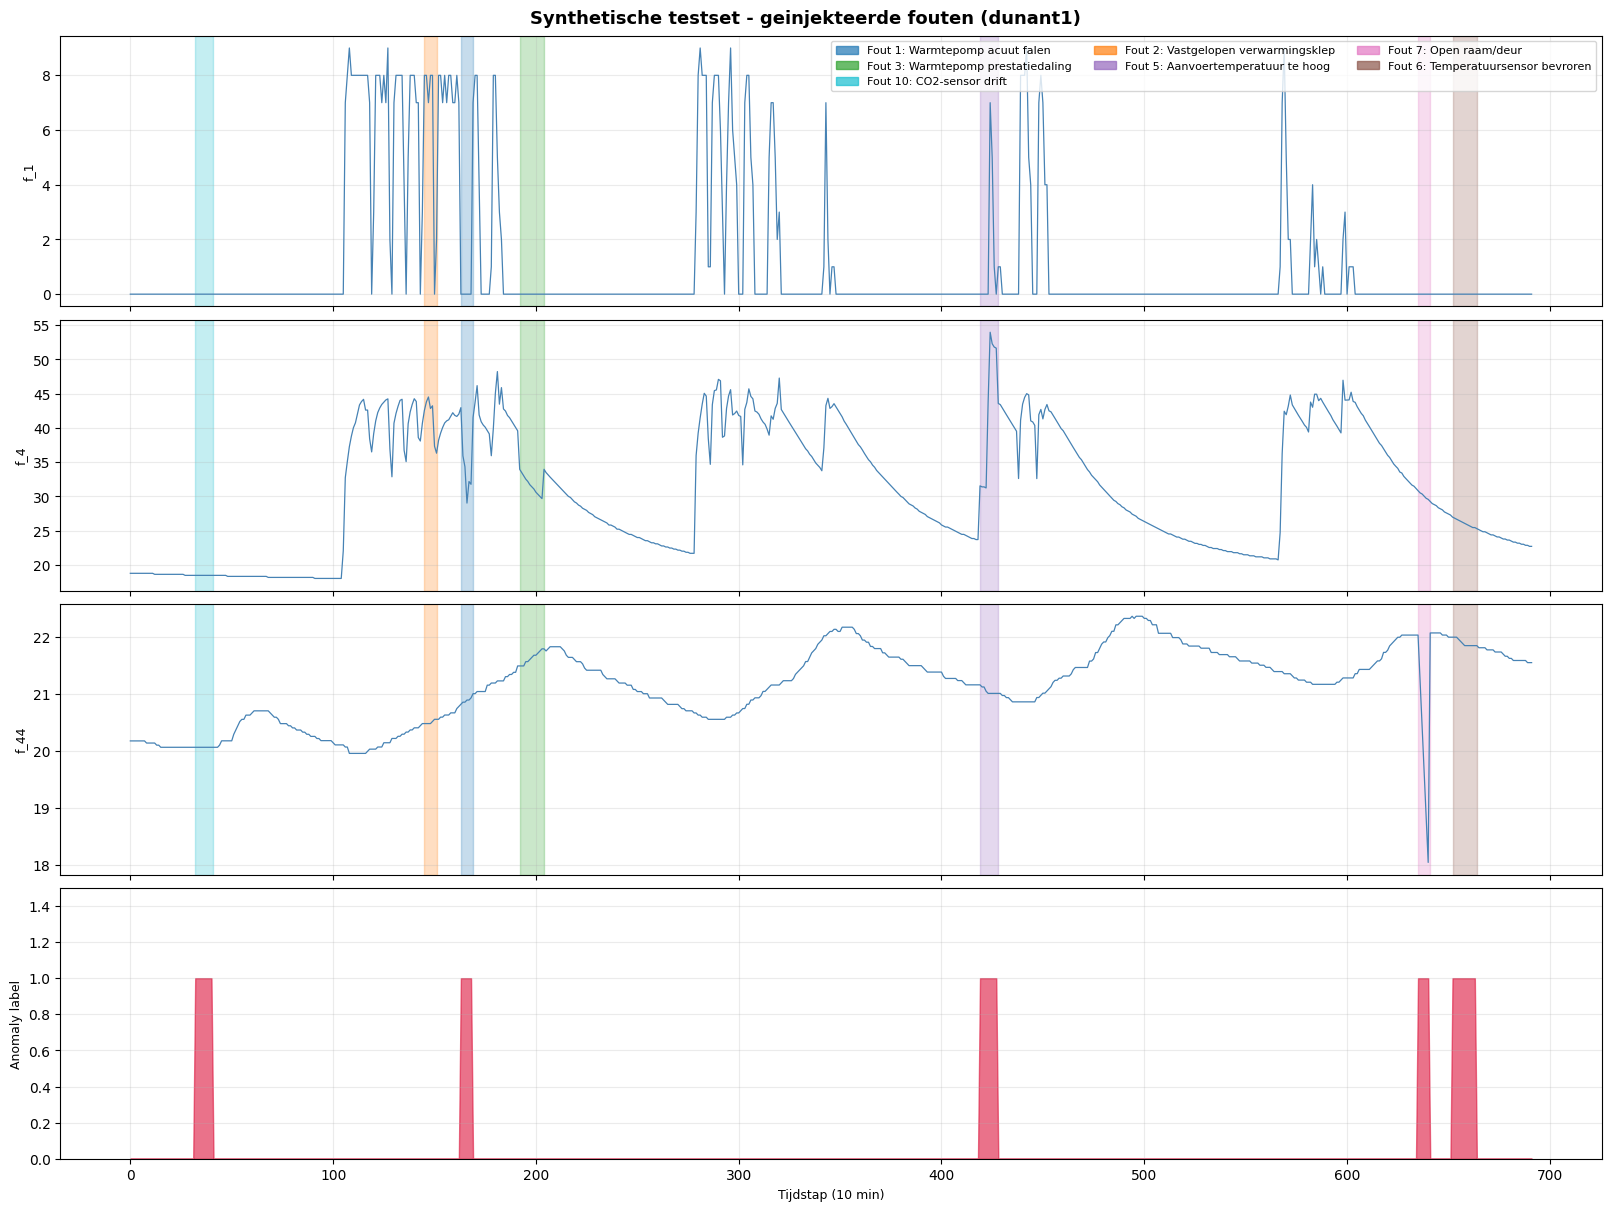

Anomalierate: 6.1%  (42 van 692 tijdstappen)


In [7]:
# Visualisatie: testset tijdreeks met geinjekteerde foutvensters
import matplotlib.patches as mpatches

candidates = ["f_1", "f_4", "f_44", "f_10", "f_27", "f_45"]
plot_feats = [f for f in candidates if f in test_data.columns][:3]
if not plot_feats:
    plot_feats = test_data.select_dtypes("number").columns[:3].tolist()

colors = plt.cm.tab10(np.linspace(0, 0.9, 10))
n_ax   = len(plot_feats)

fig, axes = plt.subplots(n_ax + 1, 1, figsize=(16, 3 * (n_ax + 1)),
                          sharex=True, constrained_layout=True)
fig.suptitle(f"Synthetische testset - geinjekteerde fouten ({GEBOUWNAAM})",
             fontsize=13, fontweight="bold")

for ax, feat in zip(axes[:n_ax], plot_feats):
    ax.plot(range(len(test_data)), test_data[feat].values,
            color="steelblue", lw=0.9)
    for flt in fault_metadata["faults"]:
        ax.axvspan(flt["start_idx"], flt["end_idx"],
                   alpha=0.25, color=colors[flt["id"] - 1])
    ax.set_ylabel(feat, fontsize=9)
    ax.grid(alpha=0.25)

ax_lbl = axes[-1]
ax_lbl.fill_between(range(len(labels)), labels, alpha=0.6, color="crimson")
ax_lbl.set_ylim(0, 1.5)
ax_lbl.set_ylabel("Anomaly label", fontsize=9)
ax_lbl.set_xlabel("Tijdstap (10 min)", fontsize=9)
ax_lbl.grid(alpha=0.25)

patches = [mpatches.Patch(color=colors[f["id"] - 1], alpha=0.7,
                           label=f"Fout {f['id']}: {f['name']}")
           for f in fault_metadata["faults"]]
axes[0].legend(handles=patches, fontsize=8, loc="upper right",
               ncol=min(len(patches), 3))
plt.show()

print(f"Anomalierate: {labels.mean()*100:.1f}%  "
      f"({int(labels.sum())} van {len(labels)} tijdstappen)")
